## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import numpy as np
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle
import gc

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x0000013DA9D63690> [0]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'

In [4]:
years = range(2009, 2024)

In [5]:
timelines = []

for year in years:
    df = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_{year}_filled.csv', encoding=enc)
    print(f'Year: {year} | {df.shape}')
    timelines.append(df)

Year: 2009 | (269005, 44)
Year: 2010 | (269005, 44)
Year: 2011 | (269005, 44)
Year: 2012 | (269742, 44)
Year: 2013 | (269005, 44)
Year: 2014 | (269005, 44)
Year: 2015 | (269005, 44)
Year: 2016 | (269742, 44)
Year: 2017 | (269005, 44)
Year: 2018 | (269005, 44)
Year: 2019 | (269005, 44)
Year: 2020 | (269742, 44)
Year: 2021 | (269005, 44)
Year: 2022 | (269005, 44)
Year: 2023 | (269005, 44)


In [6]:
# timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_2016-2018_filled.csv', encoding=enc)
# wnv_file = pd.read_csv(f'../../data/{NUTS0}_WNV_cases_GRID_2010-2021.csv', encoding=enc)

timeline_file = pd.concat(timelines, ignore_index=True, axis = 0)

In [7]:
del df
del timelines

gc.collect()

0

In [8]:
timeline_file.tail()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
4037281,24.055470,37.792330,736,2023-12-27,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,2023,12,0.217993,0.167219,-0.120509,-0.167219,0.199241,0.197932,-0.076007,-0.197932,0.032263,0.041772,0.028336,0.041772,14444.000000,14179.000000,0.000000,27,14388.645161,14071.258065,14331.642857,13965.321429,14535.354839,14092.129032,14822.233333,14215.600000,29.930024,42.005770,106.100814,721.782827,2.000000,1,1
4037282,24.055470,37.792330,736,2023-12-28,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,2023,12,0.217993,0.167219,-0.120509,-0.167219,0.199241,0.197932,-0.076007,-0.197932,0.032263,0.041772,0.028336,0.041772,14454.000000,14178.000000,0.000000,28,14388.645161,14071.258065,14331.642857,13965.321429,14535.354839,14092.129032,14822.233333,14215.600000,0.817124,34.695346,99.916062,721.782827,2.000000,1,1
4037283,24.055470,37.792330,736,2023-12-29,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,2023,12,0.217993,0.167219,-0.120509,-0.167219,0.199241,0.197932,-0.076007,-0.197932,0.032263,0.041772,0.028336,0.041772,14416.000000,14178.000000,0.000000,29,14388.645161,14071.258065,14331.642857,13965.321429,14535.354839,14092.129032,14822.233333,14215.600000,0.000000,34.098865,99.487821,721.782827,2.000000,1,1
4037284,24.055470,37.792330,736,2023-12-30,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,2023,12,0.217993,0.167219,-0.120509,-0.167219,0.199241,0.197932,-0.076007,-0.197932,0.032263,0.041772,0.028336,0.041772,14416.000000,14178.000000,0.000000,30,14388.645161,14071.258065,14331.642857,13965.321429,14535.354839,14092.129032,14822.233333,14215.600000,0.000000,32.713515,99.487821,721.782827,2.000000,1,1
4037285,24.055470,37.792330,736,2023-12-31,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,2023,12,0.217993,0.167219,-0.120509,-0.167219,0.199241,0.197932,-0.076007,-0.197932,0.032263,0.041772,0.028336,0.041772,NaN,NaN,NaN,31,14388.645161,14071.258065,14331.642857,13965.321429,14535.354839,14092.129032,14822.233333,14215.600000,0.000000,32.713515,97.593913,721.782827,2.000000,1,1


In [9]:
timeline_file.shape

(4037286, 44)

In [10]:
# wnv_file.head()

In [11]:
timeline_file['lst_day'] = timeline_file['lst_day'].replace(r'\b\d{4}-\d{2}-\d{2}\b', np.nan, regex=True)
timeline_file['lst_night'] = timeline_file['lst_night'].replace(r'\b\d{4}-\d{2}-\d{2}\b', np.nan, regex=True)

In [12]:
timeline_file['lst_day'] = timeline_file['lst_day'].astype(float)
timeline_file['lst_night'] = timeline_file['lst_night'].astype(float)

In [13]:
timeline_file['lst_night']

0         13991.000000
1         13991.000000
2         13991.000000
3         13991.000000
4         13991.000000
              ...     
4037281   14179.000000
4037282   14178.000000
4037283   14178.000000
4037284   14178.000000
4037285            NaN
Name: lst_night, Length: 4037286, dtype: float64

In [14]:
# wnv_file.shape

In [15]:
try:
    timeline_file.drop(columns=['Unnamed: 0'], inplace=True)
except KeyError:
    print ("column not found")

column not found


In [16]:
temprature_cols = timeline_file.filter(regex='^lst_*').columns.tolist()

timeline_file[temprature_cols] = timeline_file[temprature_cols].apply(lambda x : x * 0.02 - 273.15)

In [17]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,22.925360,36.229230,0,2009-01-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.430000,6.670000,0.000000,1,10.907419,8.132581,10.546429,6.066429,15.258387,7.096452,19.500667,8.885333,0.000000,0.000000,0.000000,0.000000,2.000000,1,1
1,22.925360,36.229230,0,2009-01-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.450000,6.670000,3.562209,2,10.907419,8.132581,10.546429,6.066429,15.258387,7.096452,19.500667,8.885333,3.562209,3.562209,3.562209,3.562209,2.000000,1,1
2,22.925360,36.229230,0,2009-01-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.450000,6.670000,9.715884,3,10.907419,8.132581,10.546429,6.066429,15.258387,7.096452,19.500667,8.885333,13.278093,13.278093,13.278093,13.278093,2.000000,1,1
3,22.925360,36.229230,0,2009-01-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.450000,6.670000,74.676221,4,10.907419,8.132581,10.546429,6.066429,15.258387,7.096452,19.500667,8.885333,87.954314,87.954314,87.954314,87.954314,2.000000,1,1
4,22.925360,36.229230,0,2009-01-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.450000,6.670000,176.860980,5,10.907419,8.132581,10.546429,6.066429,15.258387,7.096452,19.500667,8.885333,264.815294,264.815294,264.815294,264.815294,2.000000,1,1


In [18]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [19]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)

timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [20]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [21]:
timeline_file

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,month_sin,month_cos
0,22.925360,36.229230,0,2009-01-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.430000,6.670000,0.000000,1,10.907419,8.132581,10.546429,6.066429,15.258387,7.096452,19.500667,8.885333,0.000000,0.000000,0.000000,0.000000,2.000000,1,1,8.050000,9.520000,8.306429,11.177419,14.193000,0.500000,0.866025
1,22.925360,36.229230,0,2009-01-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.450000,6.670000,3.562209,2,10.907419,8.132581,10.546429,6.066429,15.258387,7.096452,19.500667,8.885333,3.562209,3.562209,3.562209,3.562209,2.000000,1,1,8.060000,9.520000,8.306429,11.177419,14.193000,0.500000,0.866025
2,22.925360,36.229230,0,2009-01-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.450000,6.670000,9.715884,3,10.907419,8.132581,10.546429,6.066429,15.258387,7.096452,19.500667,8.885333,13.278093,13.278093,13.278093,13.278093,2.000000,1,1,8.060000,9.520000,8.306429,11.177419,14.193000,0.500000,0.866025
3,22.925360,36.229230,0,2009-01-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.450000,6.670000,74.676221,4,10.907419,8.132581,10.546429,6.066429,15.258387,7.096452,19.500667,8.885333,87.954314,87.954314,87.954314,87.954314,2.000000,1,1,8.060000,9.520000,8.306429,11.177419,14.193000,0.500000,0.866025
4,22.925360,36.229230,0,2009-01-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.450000,6.670000,176.860980,5,10.907419,8.132581,10.546429,6.066429,15.258387,7.096452,19.500667,8.885333,264.815294,264.815294,264.815294,264.815294,2.000000,1,1,8.060000,9.520000,8.306429,11.177419,14.193000,0.500000,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4037281,24.055470,37.792330,736,2023-12-27,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,2023,12,0.217993,0.167219,-0.120509,-0.167219,0.199241,0.197932,-0.076007,-0.197932,0.032263,0.041772,0.028336,0.041772,15.730000,10.430000,0.000000,27,14.622903,8.275161,13.482857,6.156429,17.557097,8.692581,23.294667,11.162000,29.930024,42.005770,106.100814,721.782827,2.000000,1,1,13.080000,11.449032,9.819643,13.124839,17.228333,-0.000000,1.000000
4037282,24.055470,37.792330,736,2023-12-28,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,2023,12,0.217993,0.167219,-0.120509,-0.167219,0.199241,0.197932,-0.076007,-0.197932,0.032263,0.041772,0.028336,0.041772,15.930000,10.410000,0.000000,28,14.622903,8.275161,13.482857,6.156429,17.557097,8.692581,23.294667,11.162000,0.817124,34.695346,99.916062,721.782827,2.000000,1,1,13.170000,11.449032,9.819643,13.124839,17.228333,-0.000000,1.000000
4037283,24.055470,37.792330,736,2023-12-29,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,2023,12,0.217993,0.167219,-0.120509,-0.167219,0.199241,0.197932,-0.076007,-0.197932,0.032263,0.041772,0.028336,0.041772,15.170000,10.410000,0.000000,29,14.622903,8.275161,13.482857,6.156429,17.557097,8.692581,23.294667,11.162000,0.000000,34.098865,99.487821,721.782827,2.000000,1,1,12.790000,11.449032,9.819643,13.124839,17.228333,-0.000000,1.000000
4037284,24.055470,37.792330,736,20

In [22]:
timeline_file.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
timeline_file['date_string'] = timeline_file['month'].astype(str) + '-' + timeline_file['year'].astype(str)
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['date_string'], format='%m-%Y').dt.to_period('M')
timeline_file.drop(columns=['date_string'], inplace = True)

In [23]:
gc.collect()

0

In [24]:
grouped_by_month = timeline_file.drop(columns=['dt_placement_daily']).groupby(['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME'], as_index = False)

grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

In [25]:
del timeline_file
gc.collect()

0

In [26]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mean[['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME','x','y','MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_min[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_min', 'lst_night': 'lst_night_min'}),
                                     grouped_by_month_max[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_max', 'lst_night': 'lst_night_max'}),
                                     grouped_by_month_sum[['rainfall']].rename(columns={'rainfall':'rainfall_acc'})], axis=1)

In [27]:
del grouped_by_month
del grouped_by_month_mean
del grouped_by_month_min
del grouped_by_month_max
del grouped_by_month_sum
del grouped_by_month_last

gc.collect()

0

In [28]:
grouped_by_month_dataset.head()

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2009-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2009.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.907419,8.132581,9.520000,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,15.439096,86.815065,114.181245,478.611967,478.611967,4.450000,4.130000,15.510000,10.530000,478.611967
1,0,2009-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2009.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.546429,6.066429,8.306429,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,6.991162,34.645614,66.767847,199.896512,674.364499,0.310000,1.470000,14.830000,11.150000,195.752531
2,0,2009-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2009.000000,3.000000,0.394683,0.097761,-0.297027,-0.097761,0.379386,0.097787,-0.270868,-0.097787,0.045269,0.027451,0.048790,0.027451,15.258387,7.096452,11.177419,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,4.211311,12.417633,25.670973,124.823961,804.915144,9.830000,3.030000,19.790000,10.090000,130.550646
3,0,2009-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2009.000000,4.000000,0.394683,0.097761,-0.297027,-0.097761,0.379386,0.097787,-0.270868,-0.097787,0.045269,0.027451,0.048790,0.027451,19.500667,8.885333,14.193000,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,4.583124,4.529084,13.596775,137.493718,942.408862,11.070000,5.950000,25.370000,11.450000,137.493718
4,0,2009-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2009.000000,5.000000,0.362634,0.048065,-0.332113,-0.048065,0.369133,0.061589,-0.317565,-0.061589,0.041174,0.032687,0.017196,0.032687,26.555161,14.202903,20.379032,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,2.192089,2.200641,3.731027,67.737961,1010.363606,16.850000,9.670000,35.450000,19.790000,67.954744


In [29]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2009-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2009.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.907419,8.132581,9.520000,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,15.439096,86.815065,114.181245,478.611967,478.611967,4.450000,4.130000,15.510000,10.530000,478.611967
1,0,2009-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2009.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.546429,6.066429,8.306429,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,6.991162,34.645614,66.767847,199.896512,674.364499,0.310000,1.470000,14.830000,11.150000,195.752531
2,0,2009-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2009.000000,3.000000,0.394683,0.097761,-0.297027,-0.097761,0.379386,0.097787,-0.270868,-0.097787,0.045269,0.027451,0.048790,0.027451,15.258387,7.096452,11.177419,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,4.211311,12.417633,25.670973,124.823961,804.915144,9.830000,3.030000,19.790000,10.090000,130.550646
3,0,2009-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2009.000000,4.000000,0.394683,0.097761,-0.297027,-0.097761,0.379386,0.097787,-0.270868,-0.097787,0.045269,0.027451,0.048790,0.027451,19.500667,8.885333,14.193000,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,4.583124,4.529084,13.596775,137.493718,942.408862,11.070000,5.950000,25.370000,11.450000,137.493718
4,0,2009-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2.000000,1.000000,1.000000,2009.000000,5.000000,0.362634,0.048065,-0.332113,-0.048065,0.369133,0.061589,-0.317565,-0.061589,0.041174,0.032687,0.017196,0.032687,26.555161,14.202903,20.379032,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,2.192089,2.200641,3.731027,67.737961,1010.363606,16.850000,9.670000,35.450000,19.790000,67.954744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132655,736,2023-08,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,24.055470,37.792330,2.000000,1.000000,1.000000,2023.000000,8.000000,0.150501,-0.116416,-0.218747,0.116416,0.163173,-0.121552,-0.219210,0.121552,0.040716,0.031971,0.025059,0.031971,37.333226,24.769355,31.051290,14.622903,13.482857,17.557097,23.294667,8.275161,6.156429,8.692581,11.162000,11.449032,9.819643,13.124839,17.228333,0.263160,8.157974,8.157974,8.157974,307.968052,31.390000,22.170000,43.670000,27.450000,8.157974
132656,736,2023-09,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,24.055470,37.792330,2.000000,1.000000,1.000000,2023.000000,9.000000,0.157669,-0.091426,-0.215611,0.091426,0.170598,-0.089572,-0.214009,0.089572,0.038005,0.032348,0.024526,0.032348,34.059333,22.932667,28.496000,14.622903,13.482857,17.557097,23.294667,8.275161,6.1

In [30]:
grouped_by_month_dataset['lst_min'] = grouped_by_month_dataset.apply(lambda row: min(row['lst_day_min'], row['lst_night_min']), axis=1)
grouped_by_month_dataset['lst_max'] = grouped_by_month_dataset.apply(lambda row: max(row['lst_day_max'], row['lst_night_max']), axis=1)

In [31]:
grouped_by_month_dataset.drop(columns=['lst_day_min', 'lst_night_min', 'lst_day_max', 'lst_night_max'], inplace=True)

In [32]:
grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']] = grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']].astype(int)


In [33]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max
0,0,2009-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.907419,8.132581,9.520000,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,15.439096,86.815065,114.181245,478.611967,478.611967,478.611967,4.130000,15.510000
1,0,2009-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.546429,6.066429,8.306429,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,6.991162,34.645614,66.767847,199.896512,674.364499,195.752531,0.310000,14.830000
2,0,2009-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2009,3,0.394683,0.097761,-0.297027,-0.097761,0.379386,0.097787,-0.270868,-0.097787,0.045269,0.027451,0.048790,0.027451,15.258387,7.096452,11.177419,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,4.211311,12.417633,25.670973,124.823961,804.915144,130.550646,3.030000,19.790000
3,0,2009-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2009,4,0.394683,0.097761,-0.297027,-0.097761,0.379386,0.097787,-0.270868,-0.097787,0.045269,0.027451,0.048790,0.027451,19.500667,8.885333,14.193000,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,4.583124,4.529084,13.596775,137.493718,942.408862,137.493718,5.950000,25.370000
4,0,2009-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2009,5,0.362634,0.048065,-0.332113,-0.048065,0.369133,0.061589,-0.317565,-0.061589,0.041174,0.032687,0.017196,0.032687,26.555161,14.202903,20.379032,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,2.192089,2.200641,3.731027,67.737961,1010.363606,67.954744,9.670000,35.450000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132655,736,2023-08,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,24.055470,37.792330,2,1,1,2023,8,0.150501,-0.116416,-0.218747,0.116416,0.163173,-0.121552,-0.219210,0.121552,0.040716,0.031971,0.025059,0.031971,37.333226,24.769355,31.051290,14.622903,13.482857,17.557097,23.294667,8.275161,6.156429,8.692581,11.162000,11.449032,9.819643,13.124839,17.228333,0.263160,8.157974,8.157974,8.157974,307.968052,8.157974,22.170000,43.670000
132656,736,2023-09,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,24.055470,37.792330,2,1,1,2023,9,0.157669,-0.091426,-0.215611,0.091426,0.170598,-0.089572,-0.214009,0.089572,0.038005,0.032348,0.024526,0.032348,34.059333,22.932667,28.496000,14.622903,13.482857,17.557097,23.294667,8.275161,6.156429,8.692581,11.162000,11.449032,9.819643,13.124839,17.228333,3.564708,102.883267,102.883267,106.941241,414.909292,106.941241,17.210000,36.390000
132657,736,2023-10,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,24.055470,37.792330,2,1,1,2023,10,0.212386,-0.034779,-0.242145,0.034779,0.232549,-0.009582,-0.238997,0.009582,0.033478,0.036143,0.021841,0.036143,25.488065,17.066774,21.277419,14.62

### Add Geomorphological and Land Cover/Use

In [34]:
dataset_locations = grouped_by_month_dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [35]:
dataset_locations_per_year = grouped_by_month_dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [36]:
dataset_locations

,x,y
0,22.925360,36.229230
1,22.925360,36.319060
2,22.925360,36.319060
3,22.925360,36.337030
4,22.947520,36.193290
...,...,...
1116,24.055470,37.774360
1117,24.055470,37.774360
1118,24.055470,37.774360
1119,24.055470,37.792330


In [37]:
dataset_locations_per_year

,x,y,year
0,22.925360,36.229230,2009
1,22.925360,36.229230,2010
2,22.925360,36.229230,2011
3,22.925360,36.229230,2012
4,22.925360,36.229230,2013
...,...,...,...
15253,24.055470,37.792330,2021
15254,24.055470,37.792330,2022
15255,24.055470,37.792330,2022
15256,24.055470,37.792330,2023


In [38]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [39]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 2.183223232975093e-06
Max distance: 0.0004080402541026767


In [40]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_19656\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [41]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.925360,36.229230,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166
1,22.925360,36.319060,1765.480985,6926.111027,10,197.077012,274.126271,180.773995,0.000000,5.117582
2,22.925360,36.319060,1765.480985,6926.111027,10,197.077012,274.126271,180.773995,0.000000,5.117582
3,22.925360,36.337030,1903.382813,7495.847864,7,235.289966,337.325945,186.904082,0.000000,1.487290
4,22.947520,36.193290,2106.538145,3337.921859,15,286.834685,337.529195,188.715719,0.000000,1.065844
...,...,...,...,...,...,...,...,...,...,...
1116,24.055470,37.774360,2045.112663,134.017517,28,278.377388,82.546453,182.070048,0.000000,83.284376
1117,24.055470,37.774360,2045.112663,134.017517,28,278.377388,82.546453,182.070048,0.000000,83.284376
1118,24.055470,37.774360,2045.112663,134.017517,28,278.377388,82.546453,182.070048,0.000000,83.284376
1119,24.055470,37.792330,1561.708783,135.651666,8,197.391162,118.830309,177.711568,0.000000,79.889781


In [42]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [43]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [44]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [45]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.925360,36.229230,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166
1,22.925360,36.319060,1765.480985,6926.111027,10,197.077012,274.126271,180.773995,0.000000,5.117582
2,22.925360,36.319060,1765.480985,6926.111027,10,197.077012,274.126271,180.773995,0.000000,5.117582
3,22.925360,36.337030,1903.382813,7495.847864,7,235.289966,337.325945,186.904082,0.000000,1.487290
4,22.947520,36.193290,2106.538145,3337.921859,15,286.834685,337.529195,188.715719,0.000000,1.065844
...,...,...,...,...,...,...,...,...,...,...
1116,24.055470,37.774360,2045.112663,134.017517,28,278.377388,82.546453,182.070048,0.000000,83.284376
1117,24.055470,37.774360,2045.112663,134.017517,28,278.377388,82.546453,182.070048,0.000000,83.284376
1118,24.055470,37.774360,2045.112663,134.017517,28,278.377388,82.546453,182.070048,0.000000,83.284376
1119,24.055470,37.792330,1561.708783,135.651666,8,197.391162,118.830309,177.711568,0.000000,79.889781


In [46]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [47]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [48]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [49]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [50]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [51]:
landcover_2023 = landcover_2022

In [52]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2009
Min distance: 2.183223232975093e-06
Max distance: 0.0004080402541026767
Year: 2010
Min distance: 2.183223232975093e-06
Max distance: 0.0004080402541026767
Year: 2011
Min distance: 2.183223232975093e-06
Max distance: 0.0004080402541026767
Year: 2012
Min distance: 2.183223232975093e-06
Max distance: 0.0004080402541026767
Year: 2013
Min distance: 2.183223232975093e-06
Max distance: 0.0004080402541026767
Year: 2014
Min distance: 2.183223232975093e-06
Max distance: 0.0004080402541026767
Year: 2015
Min distance: 2.183223232975093e-06
Max distance: 0.0004080402541026767
Year: 2016
Min distance: 2.183223232975093e-06
Max distance: 0.0004080402541026767
Year: 2017
Min distance: 2.183223232975093e-06
Max distance: 0.0004080402541026767
Year: 2018
Min distance: 2.183223232975093e-06
Max distance: 0.0004080402541026767
Year: 2019
Min distance: 2.183223232975093e-06
Max distance: 0.0004080402541026767
Year: 2020
Min distance: 2.183223232975093e-06
Max distance: 0.0004080402541026767
Year

In [53]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [54]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,22.925360,36.229230,2009,22,83,20,83.000000,20,83,9,9,4,2,2,2,0
1,22.925360,36.319060,2009,31,81,30,81.000000,50,82,11,10,1,6,6,2,0
2,22.925360,36.337030,2009,11,92,10,89.000000,10,89,1,1,7,1,1,2,0
3,22.947520,36.193290,2009,22,86,20,86.000000,20,86,9,9,4,2,2,2,0
4,22.947520,36.211260,2009,22,74,20,74.000000,20,74,9,9,4,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15253,24.055470,37.774360,2023,31,90,30,90.000000,30,90,10,10,1,6,6,2,0
15254,24.055470,37.774360,2023,31,90,30,90.000000,30,90,10,10,1,6,6,2,0
15255,24.055470,37.774360,2023,31,90,30,90.000000,30,90,10,10,1,6,6,2,0
15256,24.055470,37.792330,2023,31,89,30,89.000000,30,89,10,10,1,6,6,2,0


In [55]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int32
lc_prop1                 int64
lc_prop1_assessment      int64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment      int64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [56]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_geo, on=['x', 'y'], how='left')

In [57]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

### Add Bio Variables ###

In [58]:
bio_values_df = grouped_by_month_dataset[['cell_number','year','month','rainfall_acc','lst_min','lst_max']]

In [59]:
bio_values_df.head(15)

,cell_number,year,month,rainfall_acc,lst_min,lst_max
0,0,2009,1,478.611967,4.130000,15.510000
1,0,2009,2,195.752531,0.310000,14.830000
2,0,2009,3,130.550646,3.030000,19.790000
3,0,2009,4,137.493718,5.950000,25.370000
4,0,2009,5,67.954744,9.670000,35.450000
5,0,2009,6,16.712182,14.750000,37.550000
6,0,2009,7,6.120393,17.930000,42.490000
7,0,2009,8,13.185555,17.950000,37.950000
8,0,2009,9,92.579550,14.930000,34.850000
9,0,2009,10,454.043171,12.350000,29.270000


In [60]:
# wnv_file.head(5)

In [61]:
# wnv_file

In [62]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132660 entries, 0 to 132659
Data columns (total 72 columns):
 #   Column               Non-Null Count   Dtype    
---  ------               --------------   -----    
 0   cell_number          132660 non-null  int64    
 1   dt_placement         132660 non-null  period[M]
 2   NUTS1_ID             132660 non-null  object   
 3   NUTS1_NAME           132660 non-null  object   
 4   NUTS2_ID             132660 non-null  object   
 5   NUTS2_NAME           132660 non-null  object   
 6   NUTS3_ID             132660 non-null  object   
 7   NUTS3_NAME           132660 non-null  object   
 8   LAU1_NAME            132660 non-null  object   
 9   x                    132660 non-null  float64  
 10  y                    132660 non-null  float64  
 11  MOUNT_TYPE           132660 non-null  int32    
 12  URBN_TYPE            132660 non-null  int32    
 13  COAST_TYPE           132660 non-null  int32    
 14  year                 132660 non-null

In [63]:
# wnv_file.info()

In [64]:
# wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [65]:
# wnv_file.info()

In [66]:
# wnv_file

In [67]:
# wnv_file['cases'].value_counts()

In [68]:
# wnv_file.cases.sum()

In [69]:
# merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'cell_code'] )
merged = grouped_by_month_dataset

In [70]:
merged

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,0,2009-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.907419,8.132581,9.520000,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,15.439096,86.815065,114.181245,478.611967,478.611967,478.611967,4.130000,15.510000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,83,20,83.000000,20,83,9,9,4,2,2,2,0
1,0,2009-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.546429,6.066429,8.306429,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,6.991162,34.645614,66.767847,199.896512,674.364499,195.752531,0.310000,14.830000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,83,20,83.000000,20,83,9,9,4,2,2,2,0
2,0,2009-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2009,3,0.394683,0.097761,-0.297027,-0.097761,0.379386,0.097787,-0.270868,-0.097787,0.045269,0.027451,0.048790,0.027451,15.258387,7.096452,11.177419,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,4.211311,12.417633,25.670973,124.823961,804.915144,130.550646,3.030000,19.790000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,83,20,83.000000,20,83,9,9,4,2,2,2,0
3,0,2009-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2009,4,0.394683,0.097761,-0.297027,-0.097761,0.379386,0.097787,-0.270868,-0.097787,0.045269,0.027451,0.048790,0.027451,19.500667,8.885333,14.193000,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,4.583124,4.529084,13.596775,137.493718,942.408862,137.493718,5.950000,25.370000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,83,20,83.000000,20,83,9,9,4,2,2,2,0
4,0,2009-05,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2009,5,0.362634,0.048065,-0.332113,-0.048065,0.369133,0.061589,-0.317565,-0.061589,0.041174,0.032687,0.017196,0.032687,26.555161,14.202903,20.379032,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,2.192089,2.200641,3.731027,67.737961,1010.363606,67.954744,9.670000,35.450000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,83,20,83.000000,20,83,9,9,4,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132655,736,2023-08,EL3,αττικη,EL30,αττικη,EL305,ανατολικη αττικη,λαυρεωτικης,24.055470,37.792330,2,1,1,2023,8,0.150501,-0.116416,-0.218747,0.116416,0.163173,-0.121552,-0.219210,0.121552,0.040716,0.031971,0.025059,0

In [71]:
# merged = fillna(merged,{'cases': 0})

In [72]:
# merged['cases'].value_counts()

In [73]:
# merged.cases.sum()

In [74]:
# merged = merged.astype({'cases': 'int'})

<Axes: >

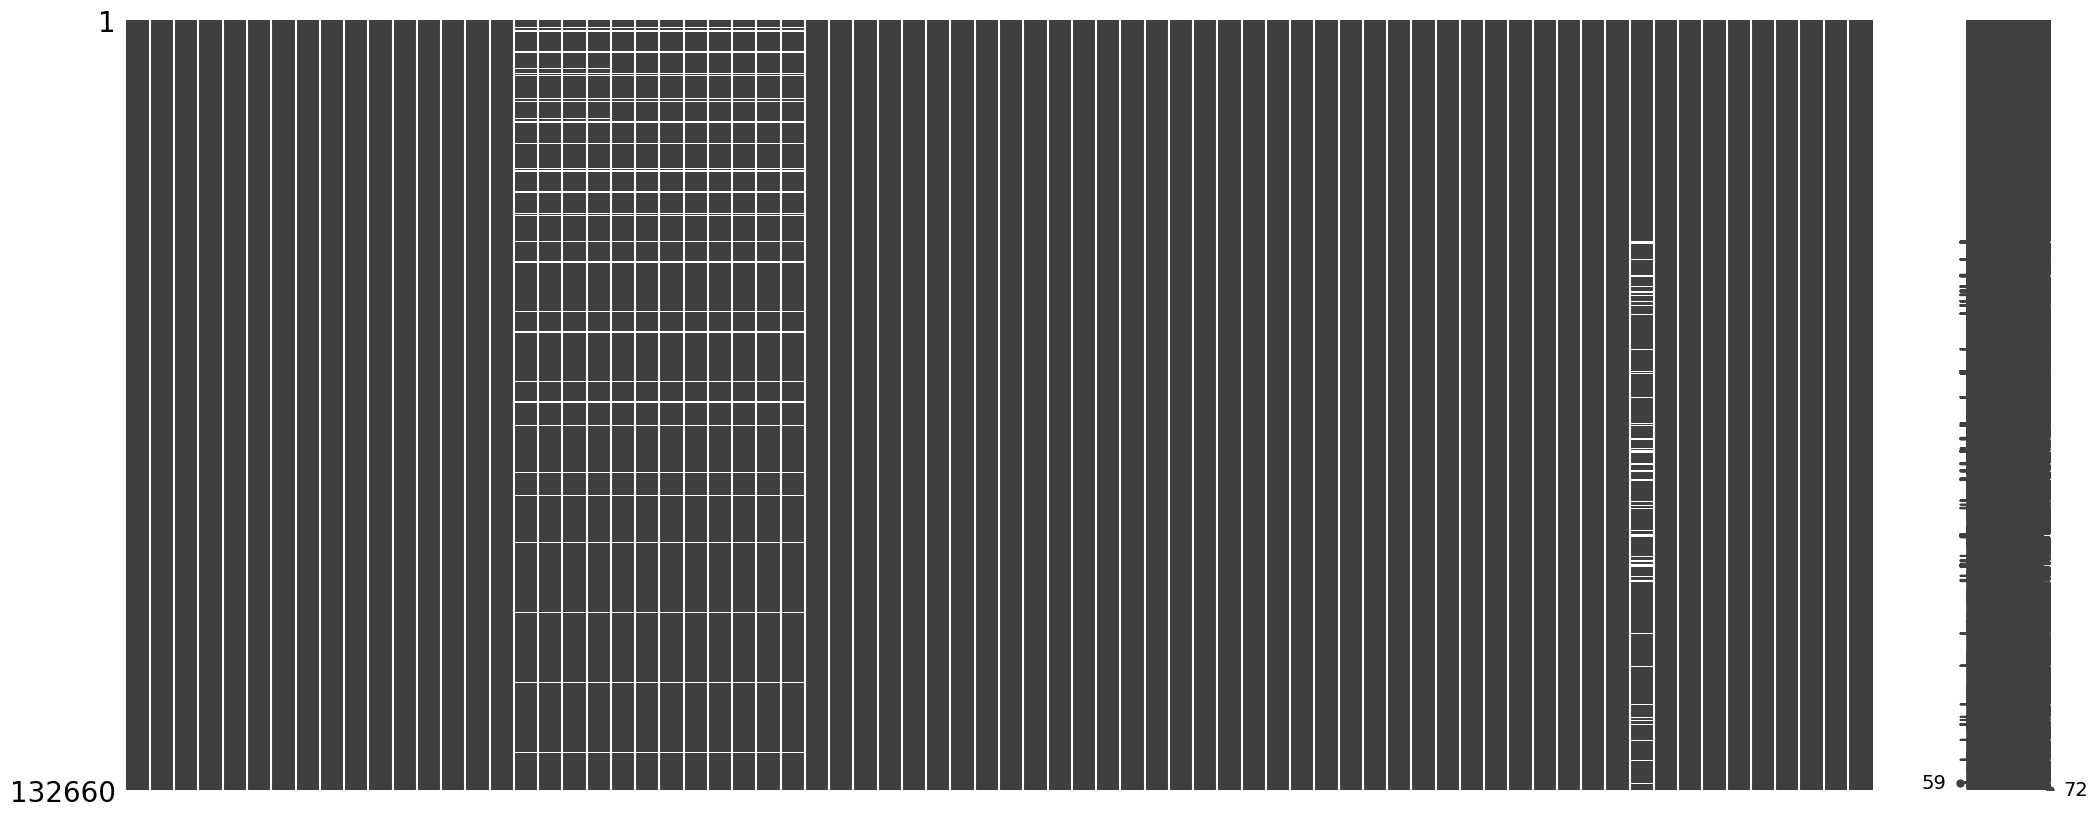

In [75]:
missingno.matrix(merged)

In [76]:
gc.collect()

0

In [77]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'lst_min', 'lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)
imputed_columns = ['lst_min', 'lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

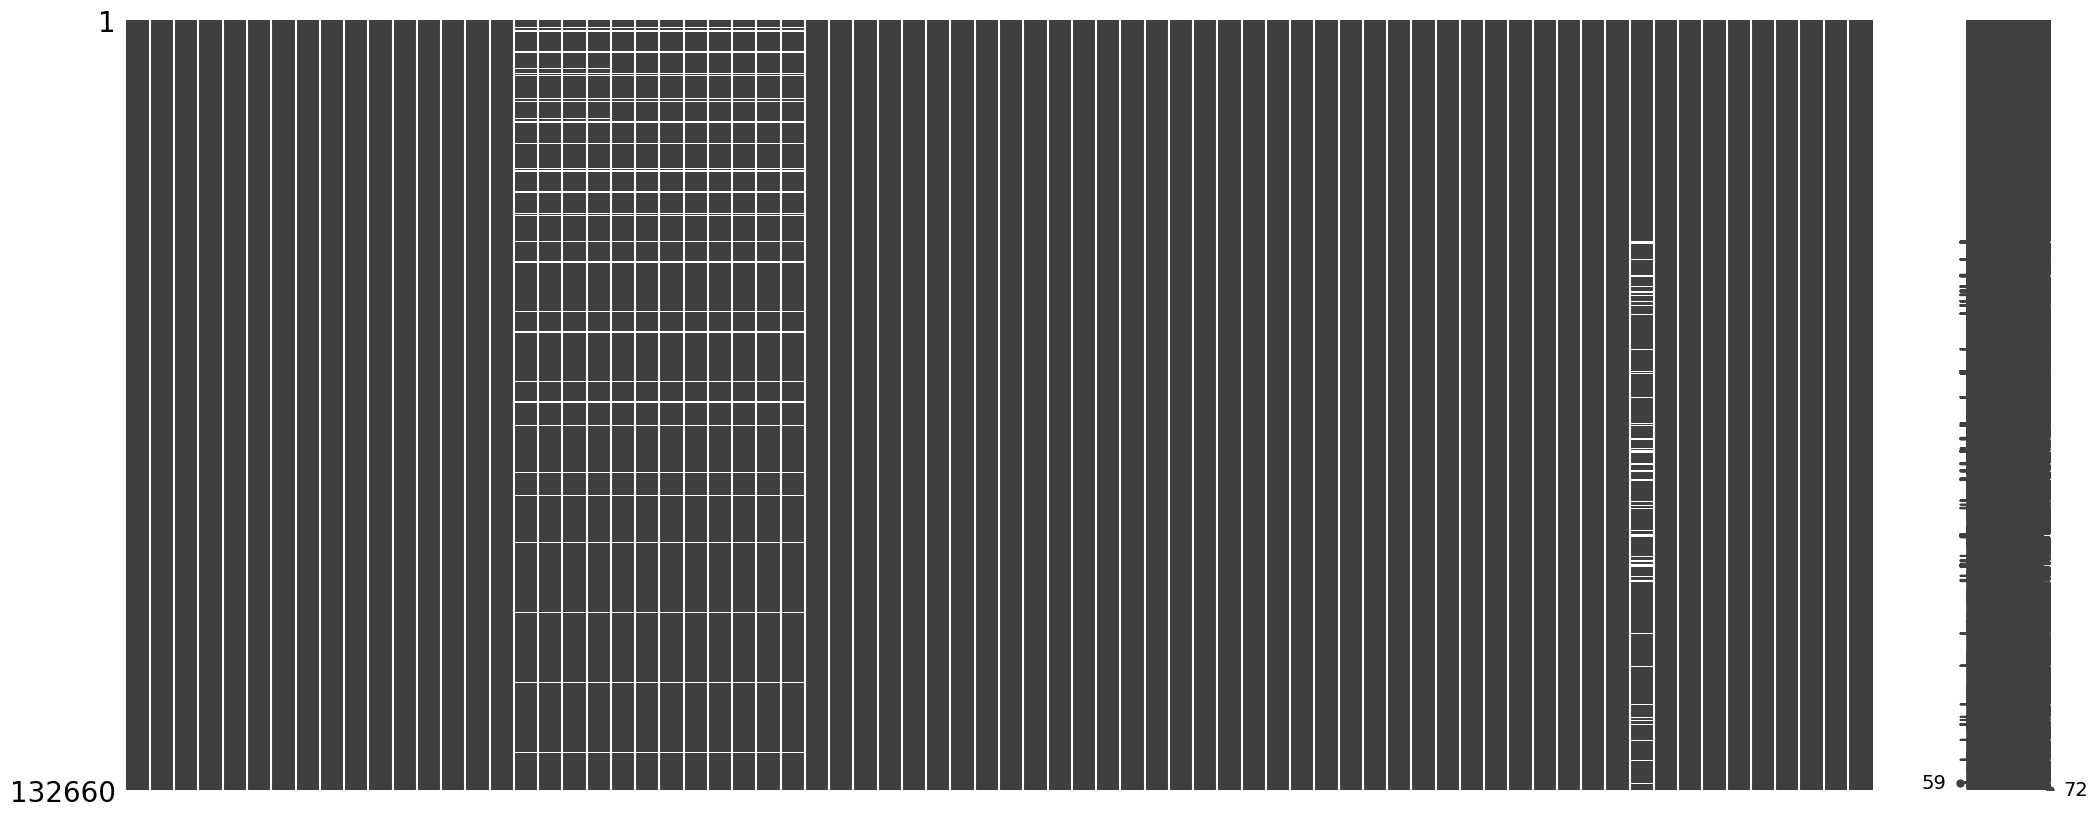

In [78]:
missingno.matrix(merged)

In [79]:
years = merged.year.unique()
years

array([2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023])

In [80]:
cell_codes_un = merged.cell_number.unique()
cell_codes_un

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [81]:
rows = []
for year in years:
    for cell in cell_codes_un:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['cell_number'] == cell)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['rainfall_acc'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'cell_number': cell, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [82]:
biovars_df.head(20)

,cell_number,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,2009,17.833333,18.666667,44.444444,779.082600,42.000000,0.000000,42.000000,10.833333,27.333333,27.333333,8.833333,2212.000000,478.000000,6.000000,92.933810,1102.000000,35.000000,35.000000,1079.000000
1,1,2009,18.041667,17.416667,44.658120,738.689975,40.000000,1.000000,39.000000,15.666667,27.000000,27.000000,9.333333,2177.000000,536.000000,4.000000,93.902449,1120.000000,28.000000,28.000000,704.000000
2,2,2009,17.916667,15.833333,42.792793,707.695792,40.000000,3.000000,37.000000,15.500000,26.833333,26.833333,9.833333,2177.000000,536.000000,4.000000,93.902449,1120.000000,28.000000,28.000000,704.000000
3,3,2009,17.958333,18.583333,45.325203,755.121403,41.000000,0.000000,41.000000,15.333333,26.833333,26.833333,8.833333,2077.000000,457.000000,8.000000,84.315739,986.000000,61.000000,61.000000,714.000000
4,4,2009,17.625000,19.583333,46.626984,766.077672,42.000000,0.000000,42.000000,11.166667,26.333333,27.166667,9.000000,2212.000000,478.000000,6.000000,92.933810,1102.000000,35.000000,111.000000,803.000000
5,5,2009,17.833333,18.666667,43.410853,788.650554,43.000000,0.000000,43.000000,11.000000,27.333333,27.333333,8.666667,2212.000000,478.000000,6.000000,92.933810,1102.000000,35.000000,35.000000,803.000000
6,6,2009,17.583333,17.666667,44.166667,736.957299,41.000000,1.000000,40.000000,11.500000,26.333333,26.666667,9.000000,2212.000000,478.000000,6.000000,92.933810,1102.000000,35.000000,111.000000,803.000000
7,7,2009,17.250000,19.333333,37.908497,828.059067,41.000000,-10.000000,51.000000,9.500000,26.333333,27.000000,6.833333,2212.000000,478.000000,6.000000,92.933810,1102.000000,35.000000,111.000000,1079.000000
8,8,2009,17.958333,17.750000,45.512821,732.510730,41.000000,2.000000,39.000000,11.666667,26.500000,27.000000,9.333333,2212.000000,478.000000,6.000000,92.933810,1102.000000,35.000000,111.000000,803.000000
9,9,2009,18.250000,18.000000,43.902439,750.000000,42.000000,1.000000,41.000000,15.666667,27.166667,27.333333,9.500000,2177.000000,536.000000,4.000000,93.902449,1120.000000,28.000000,158.000000,704.000000


In [83]:
merged = pd.merge(merged, biovars_df,  how='left', on=['cell_number', 'year'])

In [84]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2017) & (merged['cell_number'] == 0)]

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
96,0,2017-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2017,1,0.320983,-0.065077,-0.315225,0.065077,0.338934,-0.000577,-0.299791,0.000577,0.039617,0.063880,0.047819,0.063880,8.614516,5.713226,7.163871,8.614516,13.005714,16.471290,19.667333,5.713226,4.836429,9.388065,10.612667,7.163871,8.921071,12.929677,15.140000,9.868986,9.473027,148.672731,305.381857,305.938569,305.938569,-1.610000,14.310000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,91,20,91.000000,20,91,9,9,4,2,2,2,0,18.250000,19.166667,43.560606,818.674094,42.000000,-2.000000,44.000000,10.166667,28.333333,28.333333,7.833333,2303.000000,962.000000,4.000000,133.910901,1433.000000,64.000000,64.000000,678.000000
97,0,2017-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2017,2,0.307796,-0.027721,-0.295197,0.027721,0.331896,0.016421,-0.297595,-0.016421,0.036822,0.040848,0.030056,0.040848,13.005714,4.836429,8.921071,8.614516,13.005714,16.471290,19.667333,5.713226,4.836429,9.388065,10.612667,7.163871,8.921071,12.929677,15.140000,7.410268,8.991146,12.621684,208.860727,513.426073,207.487504,-2.770000,16.570000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,91,20,91.000000,20,91,9,9,4,2,2,2,0,18.250000,19.166667,43.560606,818.674094,42.000000,-2.000000,44.000000,10.166667,28.333333,28.333333,7.833333,2303.000000,962.000000,4.000000,133.910901,1433.000000,64.000000,64.000000,678.000000
98,0,2017-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2017,3,0.292843,0.004913,-0.268773,-0.004913,0.314003,0.037067,-0.276232,-0.037067,0.033647,0.029666,0.024206,0.029666,16.471290,9.388065,12.929677,8.614516,13.005714,16.471290,19.667333,5.713226,4.836429,9.388065,10.612667,7.163871,8.921071,12.929677,15.140000,4.852546,34.387001,48.279032,150.395999,663.855010,150.428937,6.230000,23.750000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,91,20,91.000000,20,91,9,9,4,2,2,2,0,18.250000,19.166667,43.560606,818.674094,42.000000,-2.000000,44.000000,10.166667,28.333333,28.333333,7.833333,2303.000000,962.000000,4.000000,133.910901,1433.000000,64.000000,64.000000,678.000000
99,0,2017-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2017,4,0.359477,-0.003222,-0.351171,0.003222,0.310577,0.030502,-0.296107,-0.030502,0.046585,0.022032,0.040980,0.022032,19.667333,10.612667,15.140000,8.614516,13.005714,16.471290,19.667333,5.713226,4.836429,9.388065,10.612667,7.163871,8.921071,12.929677,15.140000,3.391857,1.240708,78.630782,101.755700,765.610710,101.755700,7.010000,27.790000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,91,20,91.000000,20,91,9,9,4,2,2,2,0,18.250000,19.166667,43.560606,818.674094,42.000000,-2.000000,44.000000,10.166667,28.333333,28.333333,7.833333,2303.000000,962.000000,4.000000,133.910901,1433.000000,64.000000,64.000000,678.000000
100,0,2017-05,EL3,αττικη,EL30,αττικη,

In [85]:
df_demographics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [86]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [87]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [88]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [89]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

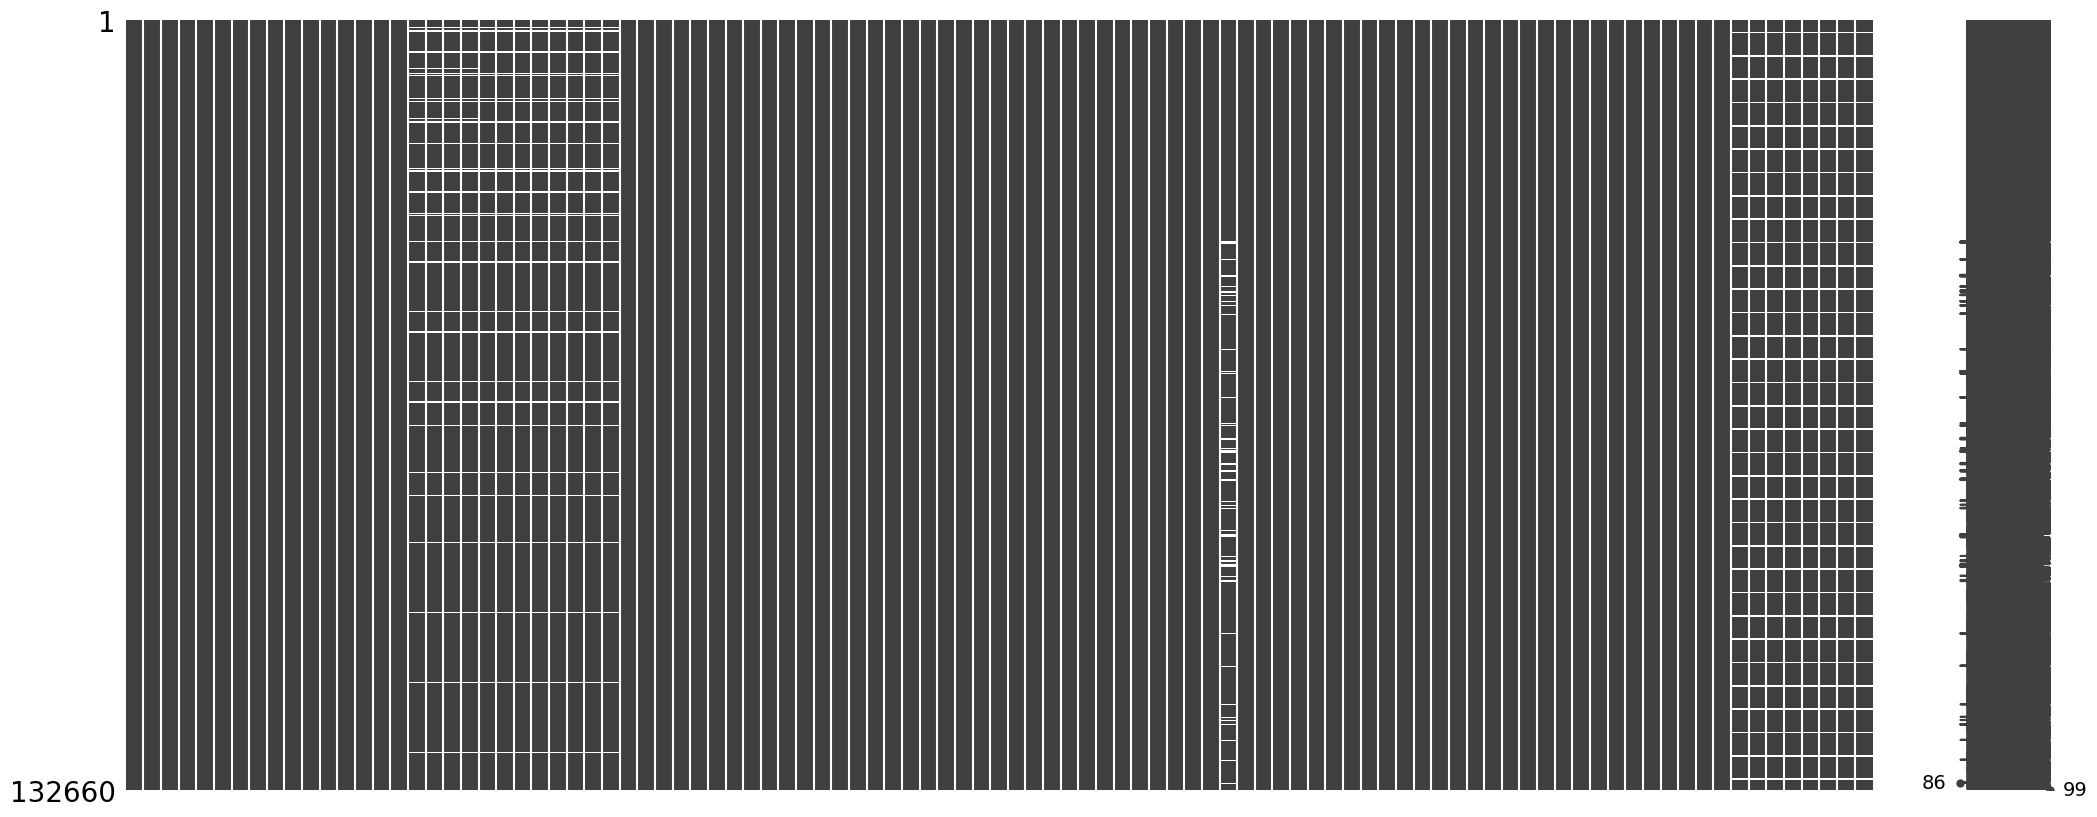

In [90]:
missingno.matrix(dataset)

In [91]:
df_economics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [92]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [93]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [94]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [95]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

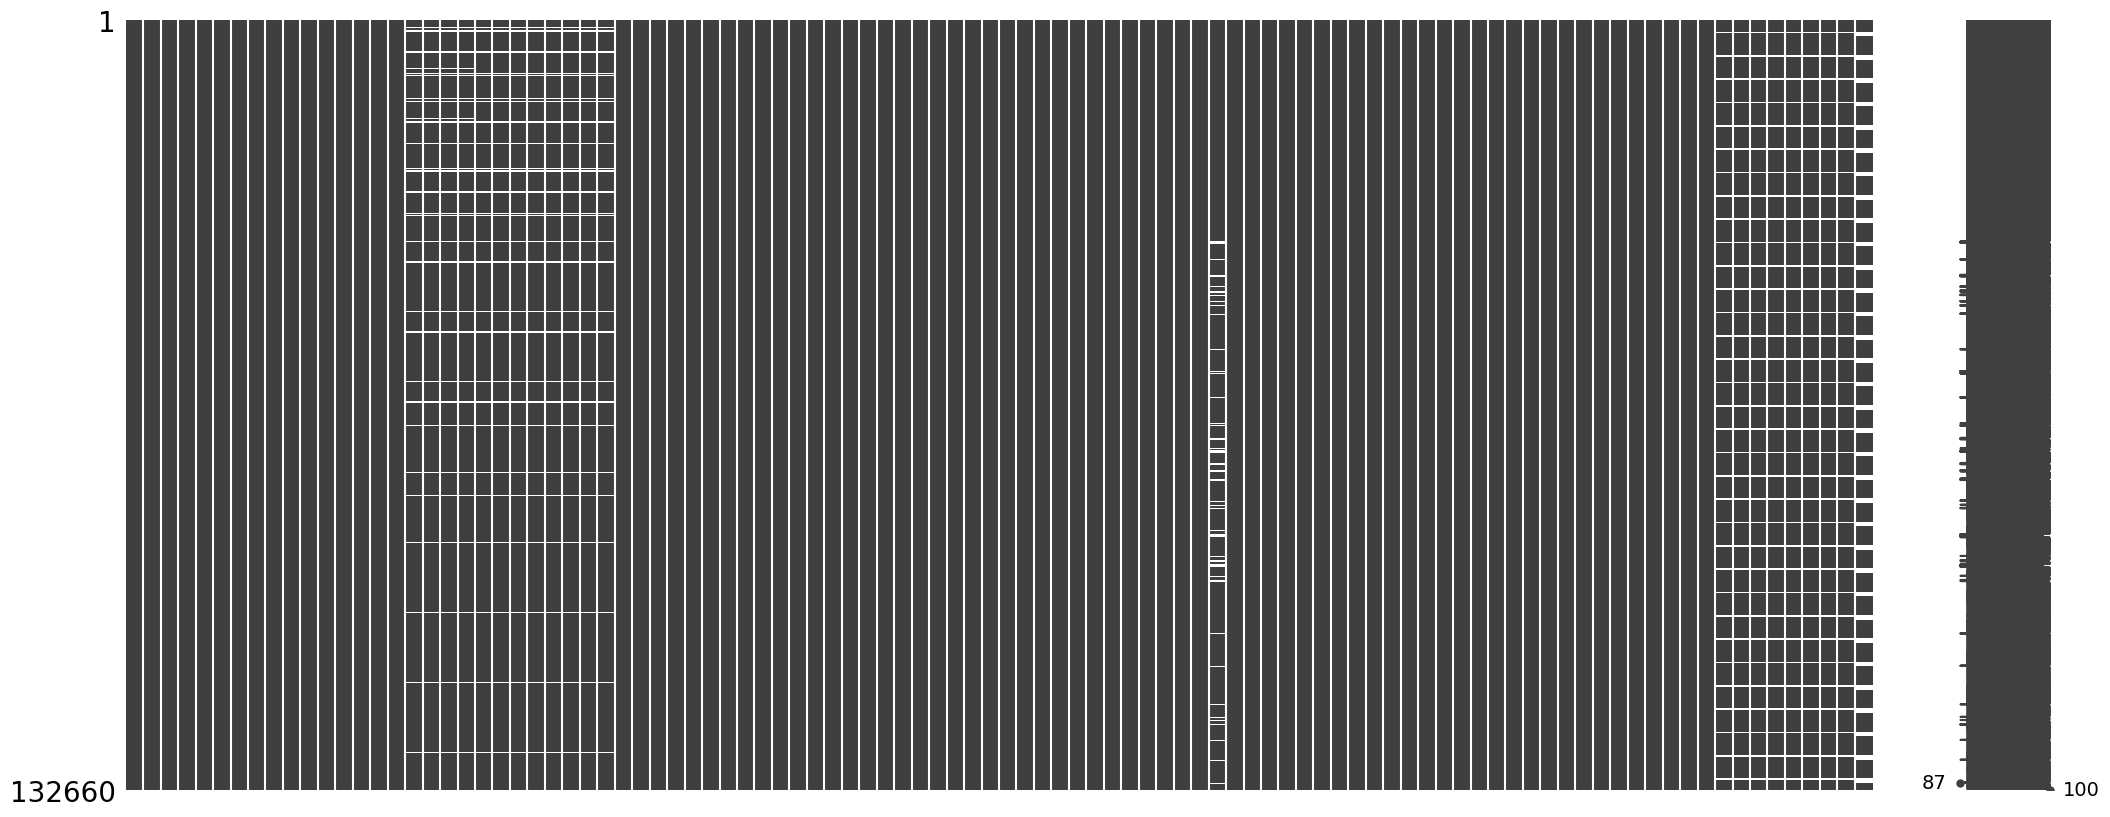

In [96]:
missingno.matrix(dataset)

In [97]:
df_trade = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [98]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [99]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [100]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [101]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

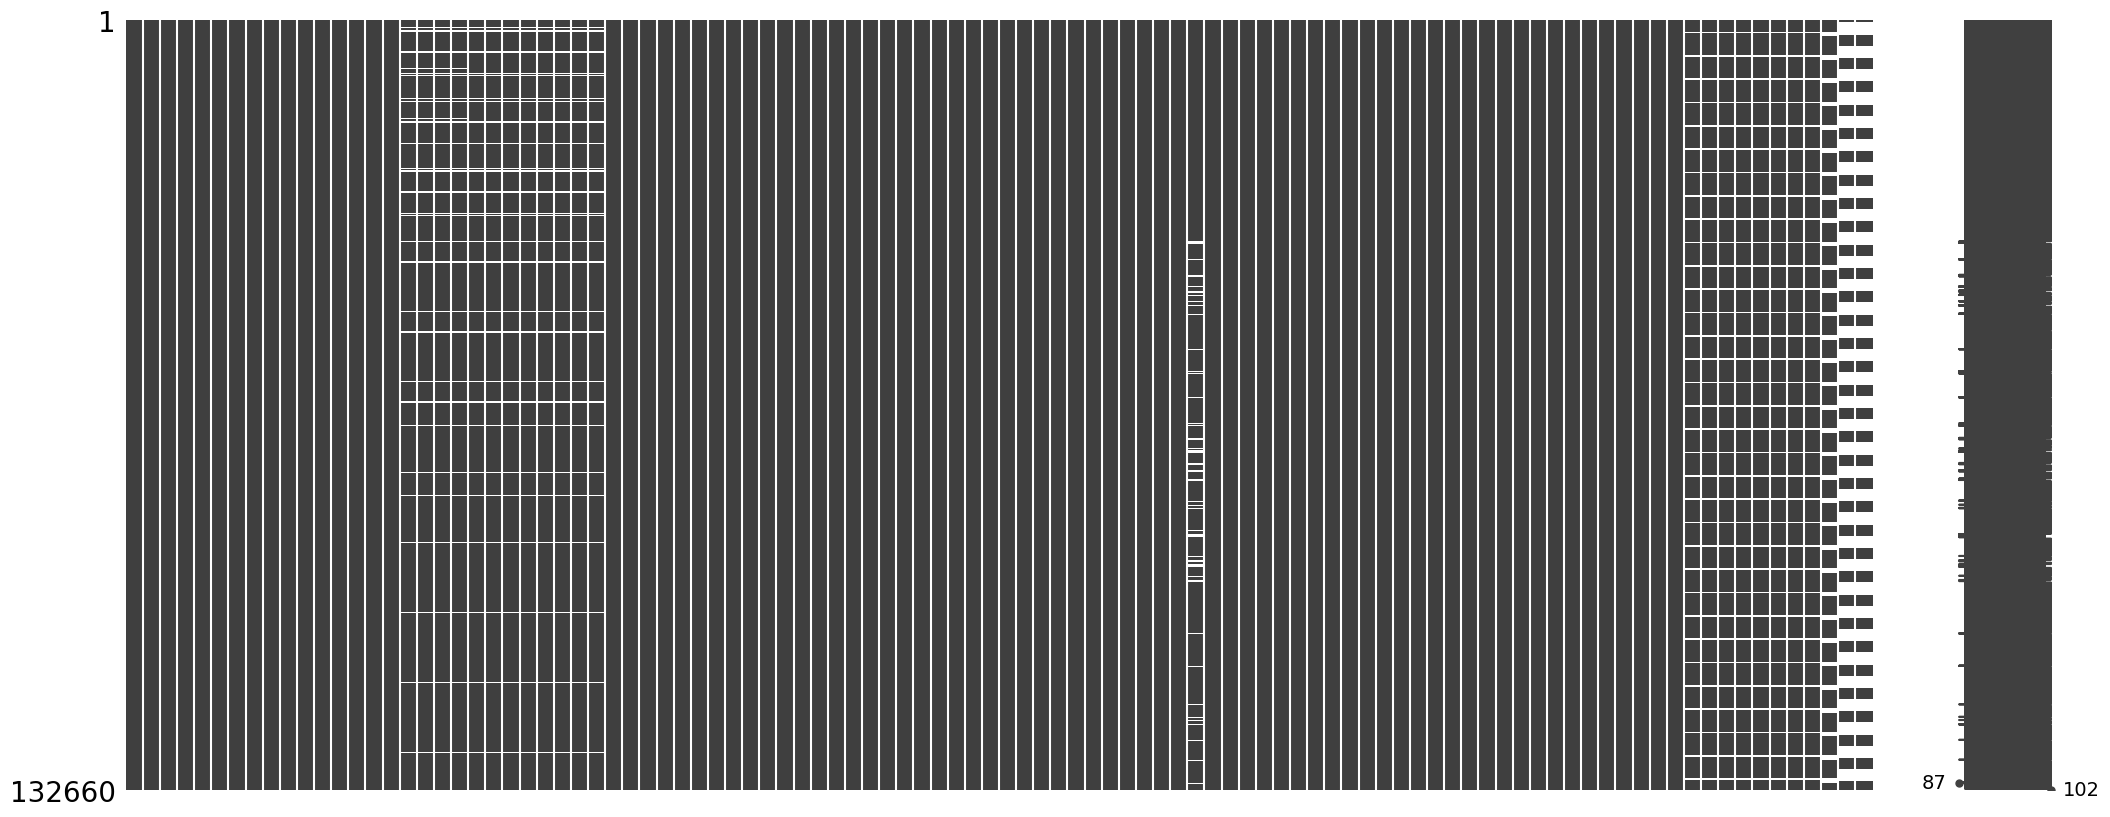

In [102]:
missingno.matrix(dataset)

In [103]:
missing = describe_dataframe(dataset, remove_zeros=True)

In [104]:
missing

,Column,Missing
16,ndvi,5.619600
17,ndmi,5.619600
18,ndwi,5.619600
19,ndbi,5.619600
20,ndvi_mean,4.945700
21,ndmi_mean,4.945700
22,ndwi_mean,4.945700
23,ndbi_mean,4.945700
24,ndvi_std,4.945700
25,ndmi_std,4.945700


In [105]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2009-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.907419,8.132581,9.520000,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,15.439096,86.815065,114.181245,478.611967,478.611967,478.611967,4.130000,15.510000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,83,20,83.000000,20,83,9,9,4,2,2,2,0,17.833333,18.666667,44.444444,779.082600,42.000000,0.000000,42.000000,10.833333,27.333333,27.333333,8.833333,2212.000000,478.000000,6.000000,92.933810,1102.000000,35.000000,35.000000,1079.000000,38177.000000,191548.000000,41050.000000,270775.000000,36486.000000,188403.000000,54929.000000,279818.000000,13405.160000,NaN,NaN
1,0,2009-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.546429,6.066429,8.306429,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,6.991162,34.645614,66.767847,199.896512,674.364499,195.752531,0.310000,14.830000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,83,20,83.000000,20,83,9,9,4,2,2,2,0,17.833333,18.666667,44.444444,779.082600,42.000000,0.000000,42.000000,10.833333,27.333333,27.333333,8.833333,2212.000000,478.000000,6.000000,92.933810,1102.000000,35.000000,35.000000,1079.000000,38177.000000,191548.000000,41050.000000,270775.000000,36486.000000,188403.000000,54929.000000,279818.000000,13405.160000,NaN,NaN
2,0,2009-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2009,3,0.394683,0.097761,-0.297027,-0.097761,0.379386,0.097787,-0.270868,-0.097787,0.045269,0.027451,0.048790,0.027451,15.258387,7.096452,11.177419,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,4.211311,12.417633,25.670973,124.823961,804.915144,130.550646,3.030000,19.790000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,83,20,83.000000,20,83,9,9,4,2,2,2,0,17.833333,18.666667,44.444444,779.082600,42.000000,0.000000,42.000000,10.833333,27.333333,27.333333,8.833333,2212.000000,478.000000,6.000000,92.933810,1102.000000,35.000000,35.000000,1079.000000,38177.000000,191548.000000,41050.000000,270775.000000,36486.000000,188403.000000,54929.000000,279818.000000,13405.160000,NaN,NaN
3,0,2009-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2009,4,0.394683,0.097761,-0.297027,-0.097761,0.379386,0.097787,-0.270868,-0.097787,0.045269,0.027451,0.048790,0.027451,19.500667,8.885333,14.193000,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,4.583124,4.529084,13.596775,137.493718,942.408862,137.493718,5.950000,25.370000,1

In [106]:
dataset.reset_index(inplace=True, drop=True)

In [107]:
# dataset['cases'].value_counts()

In [108]:
# dataset['cases'].sum()

In [109]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2009-01,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.907419,8.132581,9.520000,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,15.439096,86.815065,114.181245,478.611967,478.611967,478.611967,4.130000,15.510000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,83,20,83.000000,20,83,9,9,4,2,2,2,0,17.833333,18.666667,44.444444,779.082600,42.000000,0.000000,42.000000,10.833333,27.333333,27.333333,8.833333,2212.000000,478.000000,6.000000,92.933810,1102.000000,35.000000,35.000000,1079.000000,38177.000000,191548.000000,41050.000000,270775.000000,36486.000000,188403.000000,54929.000000,279818.000000,13405.160000,NaN,NaN
1,0,2009-02,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.546429,6.066429,8.306429,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,6.991162,34.645614,66.767847,199.896512,674.364499,195.752531,0.310000,14.830000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,83,20,83.000000,20,83,9,9,4,2,2,2,0,17.833333,18.666667,44.444444,779.082600,42.000000,0.000000,42.000000,10.833333,27.333333,27.333333,8.833333,2212.000000,478.000000,6.000000,92.933810,1102.000000,35.000000,35.000000,1079.000000,38177.000000,191548.000000,41050.000000,270775.000000,36486.000000,188403.000000,54929.000000,279818.000000,13405.160000,NaN,NaN
2,0,2009-03,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2009,3,0.394683,0.097761,-0.297027,-0.097761,0.379386,0.097787,-0.270868,-0.097787,0.045269,0.027451,0.048790,0.027451,15.258387,7.096452,11.177419,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,4.211311,12.417633,25.670973,124.823961,804.915144,130.550646,3.030000,19.790000,1554.806149,2545.316809,27,217.502550,313.370524,207.335062,0.000000,1.499166,22,83,20,83.000000,20,83,9,9,4,2,2,2,0,17.833333,18.666667,44.444444,779.082600,42.000000,0.000000,42.000000,10.833333,27.333333,27.333333,8.833333,2212.000000,478.000000,6.000000,92.933810,1102.000000,35.000000,35.000000,1079.000000,38177.000000,191548.000000,41050.000000,270775.000000,36486.000000,188403.000000,54929.000000,279818.000000,13405.160000,NaN,NaN
3,0,2009-04,EL3,αττικη,EL30,αττικη,EL307,"πειραιας, νησοι",κυθηρων,22.925360,36.229230,2,1,1,2009,4,0.394683,0.097761,-0.297027,-0.097761,0.379386,0.097787,-0.270868,-0.097787,0.045269,0.027451,0.048790,0.027451,19.500667,8.885333,14.193000,10.907419,10.546429,15.258387,19.500667,8.132581,6.066429,7.096452,8.885333,9.520000,8.306429,11.177419,14.193000,4.583124,4.529084,13.596775,137.493718,942.408862,137.493718,5.950000,25.370000,1

In [110]:
cols = dataset.columns

In [111]:
print(cols)


Index(['cell_number', 'dt_placement', 'NUTS1_ID', 'NUTS1_NAME', 'NUTS2_ID',
       'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME', 'x',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=102)


In [112]:
len(cols)

102

In [113]:
years = dataset.year.unique().tolist()

In [114]:
for item in years:
    dataset[dataset.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{item}.csv", encoding = enc, index = False)